# GLOBE Curation Quickstart
### Automated Data Cleaning & Master Registry Demo

This notebook demonstrates the core functionality of the GLOBE curation pipeline. It processes 10 years of water transparency data, merges it with historical site metadata, and applies heuristic cleaning to remove common crowdsourcing errors.

### What's happening under the hood?
1. **Local Sync:** Scans your `data/` folder and ensures you have the last 10 years of CSVs.
2. **Relational Build:** Creates a `SQLite` database to link measurements with site history.
3. **Heuristic Curation:** Runs the `disk` and `tube` validators to flag typos and physical impossibilities.

### How to use this notebook:
* **Cell 1:** Sets up your environment and builds the database.
* **Cell 2:** Splits the data into Secchi Disk and Transparency Tube streams.
* **Cell 3:** Runs the automated outlier detection heuristics.
* **Cell 4:** Generates a "Before & After" visualization of the data quality.

In [1]:
# =============================================================================
# 1. ENVIRONMENT SETUP & NATIVE DATA PIPELINE
# =============================================================================
import os
import datetime
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# Shift the notebook's working directory up to the project root.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

from src.database.manager import DatabaseManager
from src.curation.tube_validator import validate_tube_data
from src.curation.disk_validator import validate_secchi_data

# Calculate dynamic 10-year window
current_year = datetime.datetime.now().year
end_year = current_year - 1
start_year = end_year - 9

config = {
    'paths': {
        'observations': 'data/observations/',
        'site_info': 'data/site_info/'
    },
}

demo_db_path = 'data/demo_master_registry.sqlite'
db = DatabaseManager(demo_db_path, overwrite=True)

print(f"Executing pipeline for 10-year observation window: {start_year} - {end_year}")

df_merged = db.load_and_merge_data(config, start_year=start_year, end_year=end_year)

print(f"\n✅ Pipeline execution complete. Successfully processed {len(df_merged)} total observations.")

 -> Wiped existing database at data/demo_master_registry.sqlite
Executing pipeline for 10-year observation window: 2016 - 2025
 -> Synchronizing local data cache for years 2016-2025...
 -> Loading observations from 10 files...
 -> Generating deterministic sample tracking IDs (usid)...
 -> Normalizing site registry into relational tables...
 -> Executing temporal join across 84634 observations...

✅ Pipeline execution complete. Successfully processed 84634 total observations.


In [2]:
# =============================================================================
# 2. INSTRUMENT ROUTING & DATA PREVIEW
# =============================================================================

print("Routing temporally-merged data into instrument-specific streams...")

# Create disk and tube measurement databases
df_disk, df_tube = db.split_by_instrument(df_merged)

print(f" -> Secchi Disk records extracted: {len(df_disk):,}")
print(f" -> Transparency Tube records extracted: {len(df_tube):,}")

# Preview the head of the Transparency Tube dataset
display(df_tube[['usid', 'site_id', 'measured_on', 'tube_image_disappearance_cm', 'version_date']].head())

Routing temporally-merged data into instrument-specific streams...
 -> Secchi Disk records extracted: 13,029
 -> Transparency Tube records extracted: 73,329


,usid,site_id,measured_on,tube_image_disappearance_cm,version_date
1,b92af2659f6e9c9c2d6571defec1571b,11334,2016-01-01,100.0,2004-11-15 22:24:35.000
5,13787451fec618ff370a6bb18f93aa02,6228,2016-01-01,11.0,2005-03-07 08:25:59.000
8,46f98fd89278c7c21353453560a46f34,32843,2016-01-02,60.0,2013-12-02 06:38:05.000
9,e1d23bee7fc74c0304a33e97934f3f9e,33464,2016-01-03,3.0,2014-11-16 04:49:06.973
10,8947c18cf6c7dc7e6da93ee02258aef6,1960,2016-01-03,118.0,2001-03-06 11:22:44.000


In [3]:
# =============================================================================
# 3. CURATION DEMONSTRATION & VISUALIZATION
# =============================================================================

print("Executing automated heuristic outlier detection pipeline on ALL records...")

curated_disk = validate_secchi_data(df_disk.copy(), config)
curated_tube = validate_tube_data(df_tube.copy(), config)

# Boolean masking
censored_disk = curated_disk.get('is_censored', pd.Series(False, index=curated_disk.index)).astype(bool)
censored_tube = curated_tube.get('is_censored', pd.Series(False, index=curated_tube.index)).astype(bool)

curated_disk['is_true_error'] = ~curated_disk['passed_heuristics'].astype(bool) & ~censored_disk
curated_tube['is_true_error'] = ~curated_tube['passed_heuristics'].astype(bool) & ~censored_tube

print(f"\n✅ Curation complete. Isolated {curated_disk['is_true_error'].sum():,} Disk errors and {curated_tube['is_true_error'].sum():,} Tube errors.")


Executing automated heuristic outlier detection pipeline on ALL records...
  -> Flagged 9336 records bypassing Bayesian evaluation:
     - 5611 Right-Censored (Disk reached bottom visibly)
     - 3725 Heuristic Failures (Typos, negatives, depth contradictions)
  -> Flagged 47620 records bypassing Bayesian evaluation:
     - 45660 Right-Censored (Perfectly clear water)
     - 1960 Heuristic Failures (Typos, negatives, logical mismatches)

✅ Curation complete. Isolated 3,725 Disk errors and 1,960 Tube errors.



✅ Quickstart plot saved to: output/figures/00_quickstart_demo/kde_rug_plot.png



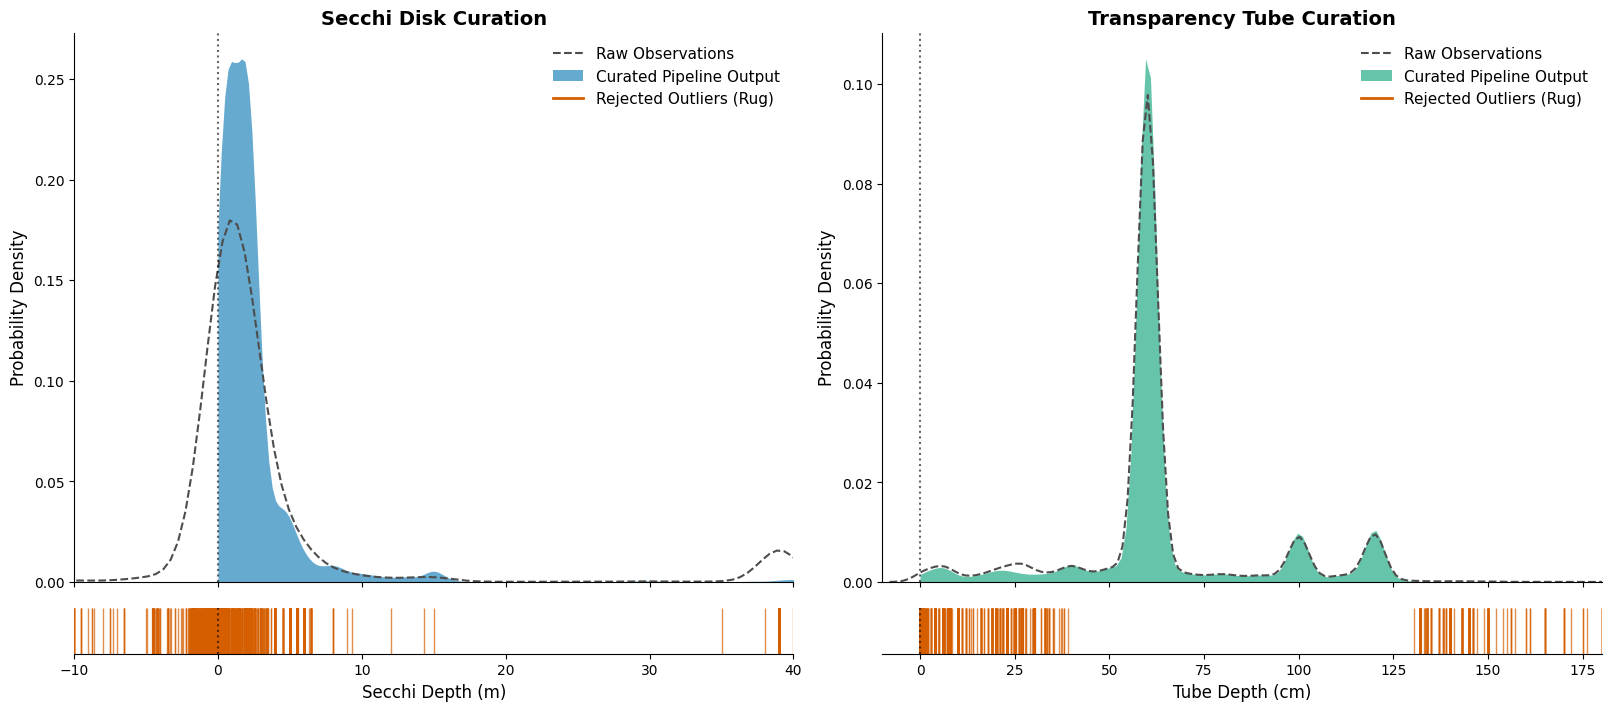


✅ Quickstart demonstration successful!


In [4]:
# =============================================================================
# 4. VISUALIZING THE CURATED DATA
# =============================================================================

# Save high resolution plot image locally
save_plot = True

# Generate demo graphic
clean_disk = curated_disk[~curated_disk['is_true_error']]
error_disk = curated_disk[curated_disk['is_true_error']]

clean_tube = curated_tube[~curated_tube['is_true_error']]
error_tube = curated_tube[curated_tube['is_true_error']]

# Color palette
color_disk = "#0072B2"  # Blue (Clean disk)
color_tube = "#009E73"  # Green (Clean tube)
color_raw = "#4D4D4D"   # Gray (Baseline)
color_rug = "#D55E00"   # Vermillion (Error markers)

# Initialize figure
fig = plt.figure(figsize=(16, 7), constrained_layout=True)
gs = GridSpec(2, 2, height_ratios=[12, 1], hspace=0.05, figure=fig)

ax_disk_kde = fig.add_subplot(gs[0, 0])
ax_disk_rug = fig.add_subplot(gs[1, 0], sharex=ax_disk_kde)

ax_tube_kde = fig.add_subplot(gs[0, 1])
ax_tube_rug = fig.add_subplot(gs[1, 1], sharex=ax_tube_kde)

# Secchi disk density plot
sns.kdeplot(data=curated_disk, x='transparency_disk_image_disappearance_m',
            color=color_raw, linestyle="--", linewidth=1.5, fill=False,
            label="Raw Observations", ax=ax_disk_kde)

sns.kdeplot(data=clean_disk, x='transparency_disk_image_disappearance_m',
            color=color_disk, fill=True, alpha=0.6, linewidth=0,
            clip=(0, None), label="Curated Pipeline Output", ax=ax_disk_kde)

ax_disk_kde.set_title("Secchi Disk Curation", fontsize=14, fontweight='bold')
ax_disk_kde.set_ylabel("Probability Density", fontsize=12)
ax_disk_kde.axvline(0, color='black', linestyle=':', alpha=0.6)

# Secchi disk rug plot
sns.rugplot(data=error_disk, x='transparency_disk_image_disappearance_m',
            color=color_rug, height=1.0, alpha=0.7, ax=ax_disk_rug)
ax_disk_rug.axvline(0, color='black', linestyle=':', alpha=0.6)
ax_disk_rug.set_xlabel("Secchi Depth (m)", fontsize=12)

# Transparency tube density plot
sns.kdeplot(data=curated_tube, x='tube_image_disappearance_cm',
            color=color_raw, linestyle="--", linewidth=1.5, fill=False,
            label="Raw Observations", ax=ax_tube_kde)

sns.kdeplot(data=clean_tube, x='tube_image_disappearance_cm',
            color=color_tube, fill=True, alpha=0.6, linewidth=0,
            clip=(0, None), label="Curated Pipeline Output", ax=ax_tube_kde)

ax_tube_kde.set_title("Transparency Tube Curation", fontsize=14, fontweight='bold')
ax_tube_kde.set_ylabel("Probability Density", fontsize=12)
ax_tube_kde.axvline(0, color='black', linestyle=':', alpha=0.6)

# Transparency tube rug plot
sns.rugplot(data=error_tube, x='tube_image_disappearance_cm',
            color=color_rug, height=1.0, alpha=0.7, ax=ax_tube_rug)
ax_tube_rug.axvline(0, color='black', linestyle=':', alpha=0.6)
ax_tube_rug.set_xlabel("Tube Depth (cm)", fontsize=12)

# Set X-axis limits
ax_disk_kde.set_xlim(-10, 40)
ax_tube_kde.set_xlim(-10, 180)

# Clean up axes
for ax_kde in [ax_disk_kde, ax_tube_kde]:
    ax_kde.spines['top'].set_visible(False)
    ax_kde.spines['right'].set_visible(False)
    ax_kde.set_xlabel("") 
    ax_kde.tick_params(labelbottom=False) 

    # Custom legend
    handles, labels = ax_kde.get_legend_handles_labels()
    rug_proxy = Line2D([0], [0], color=color_rug, lw=2, label='Rejected Outliers (Rug)')
    handles.append(rug_proxy)
    labels.append('Rejected Outliers (Rug)')
    ax_kde.legend(handles, labels, frameon=False, fontsize=11)

for ax_rug in [ax_disk_rug, ax_tube_rug]:
    ax_rug.set_yticks([])
    ax_rug.spines['top'].set_visible(False)
    ax_rug.spines['right'].set_visible(False)
    ax_rug.spines['left'].set_visible(False)

if save_plot:
    os.makedirs('output/figures/00_quickstart_demo', exist_ok=True)
    fig_path = 'output/figures/00_quickstart_demo/kde_rug_plot.png'
    plt.savefig(fig_path, bbox_inches='tight', dpi=300)
    print(f"\n✅ Quickstart plot saved to: {fig_path}\n")

plt.show()

print("\n✅ Quickstart demonstration successful!")